# Omega60 laser sampling

In [11]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 
import test
import math


## Support functions

### Spherical function plotter

In [12]:
def plot_spherical_function(theta, phi, f, name='f', title="Spherical Function"):
  f_flat = f.ravel()

  xs, ys, zs = test.sph_to_cart(1.0, theta, phi)
  points = np.column_stack((xs.ravel(), ys.ravel(), zs.ravel()))
  f_flat = f.ravel()

  cloud = pv.PolyData(points)
  cloud[name] = f_flat

  plotter = pv.Plotter()
  plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=10, scalars=name, cmap='plasma')
  plotter.add_scalar_bar(title=name, vertical=True)

  return plotter

### Plotter of sectors given theta and phi

In [13]:
def plot_spherical_sectors( theta, phi, fs, name='func', title="Spherical Sectors" ):
  """
    Interpolates spherical data (theta, phi, intensity) onto a 3D sphere mesh 
    and visualizes the distribution using PyVista.
    """
  func = sp.interpolate.RegularGridInterpolator( (theta, phi), fs, method='nearest', bounds_error=False, fill_value=0.0 )

  sphere = pv.Sphere( theta_resolution=100, phi_resolution=100 )
  r, ts, ps = test.cart_to_sph( sphere.points[:,0], sphere.points[:,1], sphere.points[:,2] )
  sphere['Data'] = func( ( ts, ps, ) )

  plotter = pv.Plotter()
  plotter.add_mesh(sphere, scalar_bar_args={'title': 'Z Position'})
  
  return plotter

### Sample of random laser points in a 2D window distribution normale

In [14]:
def sample_window( t1, t2, l1=1., l2=1., center=np.array([ 0., 0., 0., ]), num_points=1000, dist = lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), ):
  """
    Generates a set of random starting points (sampling) within a 2D rectangular 
    laser window defined by vectors t1 and t2 in 3D space.
    """
  sample = np.zeros( (num_points, 2,) )
  k = 0
  while k < num_points:
    s = dist(1)
    if np.abs(s[0,0]) <= 1.0 and np.abs(s[0,1]) <= 1.0:
      sample[k,:] = s[0,:]
      k += 1
  # map to the window
  v1 = 0.5 * l1 * t1 / np.linalg.norm( t1 )
  v2 = 0.5 * l2 * t2 / np.linalg.norm( t2 )
  return center + sample[:,0,None] * v1 + sample[:,1,None] * v2

In [15]:
t1 = np.array([ 0., 1., 0., ]) # ey
t2 = np.array([ 0., 0., 1., ]) # ez

xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=1000, )

focus = np.array([ 1., 0., 0., ])
us = focus - xs
us = us / np.linalg.norm( us, axis=1 )[:,None]

print(xs.shape)

(1000, 3)


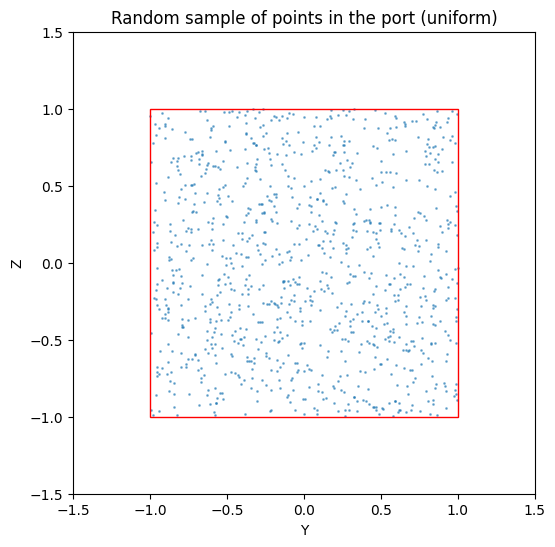

In [16]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Random sample of points in the port (uniform)")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

### Use of normal distribution in the sample of points distribution Gaussienne

In [17]:
dist = lambda num_points: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(num_points, 2))
xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=10000, dist=dist )
print(xs.shape  )

(10000, 3)


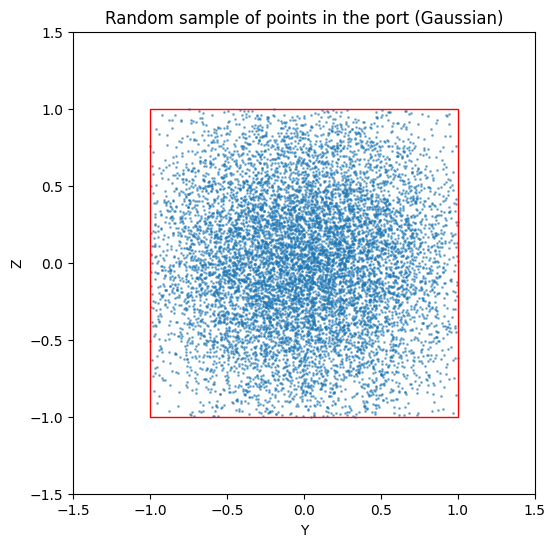

In [18]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Random sample of points in the port (Gaussian)")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

## Chamber and target geometry parameters

In [19]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Define geometry and focal distances

### Define and create beams based on Omega 60 

In [20]:
def get_omega60_dataframe():
    DEFAULT_ENERGY = 500.0     # Default beam energy [Joules]
    WAVELENGTH = 351e-9  

    omega_config= test.generare_Truncated_icosahedron()
    all_data=[]
    beam_count=1

    for r, theta, phi in omega_config:

        x, y, z= test.sph_to_cart(CHAMBER_RADIUS, theta, phi) #laser ports are on the chamber
        theta_rad=theta
        phi_rad=phi %60

        nx = np.sin(theta_rad) * np.cos(phi_rad)
        ny = np.sin(theta_rad) * np.sin(phi_rad)
        nz = np.cos(theta_rad)
        normal_u = np.array([nx, ny, nz])

        center = normal_u * CHAMBER_RADIUS

        # --- 3. Local Tangent Basis Calculation (t1, t2) ---
            # t1: Azimuthal direction vector (East-West alignment)
        t1 = np.array([-np.sin(phi_rad), np.cos(phi_rad), 0.0]) 
            
            # Singularity handling at the poles (if t1 is null)
        if np.linalg.norm(t1) < 1e-6: 
            t1 = np.array([1, 0, 0])
        t1 /= np.linalg.norm(t1)
            
            # t2: Polar direction vector (North-South alignment) via cross product
            # Completes the orthogonal right-handed coordinate system (t1, t2, normal)
        t2 = np.cross(normal_u, t1)
        t2 /= np.linalg.norm(t2)
        
        all_data.append({
                'port': f'OMEGA_J{beam_count:02d}',
                'subwindow': 0,              # Specific to OMEGA (unlike NIF quads)
                'LAT_rad': theta_rad,        # Latitude (Theta) in radians
                'LONG_rad': phi_rad,         # Longitude (Phi) in radians
                'color': 'blue' if theta < math.pi/2 else 'red',
                'energy': DEFAULT_ENERGY,
                'wavelength': WAVELENGTH,
                'center': center,            # Numpy array [x, y, z]
                'normal': normal_u,          # Numpy unit vector [nx, ny, nz]
                't1': t1,                    # First tangent vector
                't2': t2,                    # Second tangent vector
                'beam_radius': BEAM_RADIUS,
                'focus': None                # Placeholder for focusing parameters
            })
        beam_count += 1

    return pd.DataFrame(all_data)

df_omega = get_omega60_dataframe()

# Data verification
print(f"Generated columns: {df_omega.columns.tolist()}")
df_omega.head()

Generated columns: ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'center', 'normal', 't1', 't2', 'beam_radius', 'focus']


,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.203169,1.570796,blue,500.0,3.510000e-07,"[2.03859160948901e-17, 0.3329272751798081, 1.6...","[1.2355100663569759e-17, 0.20177410616958066, ...","[-1.0, 6.123233995736766e-17, 0.0]","[-5.99729184236327e-17, -0.9794320854860059, 0...",0.14,None
1,OMEGA_J02,0,0.203169,4.712389,blue,500.0,3.510000e-07,"[-6.11577482846703e-17, -0.3329272751798081, 1...","[-3.706530199070927e-17, -0.20177410616958066,...","[1.0, -1.8369701987210297e-16, 0.0]","[1.799187552708981e-16, 0.9794320854860059, 0....",0.14,None
2,OMEGA_J03,0,0.545768,0.890581,blue,500.0,3.510000e-07,"[0.5386876470026674, 0.6658545503552404, 1.410...","[0.3264773618197984, 0.4035482123365094, 0.854...","[-0.7774375248306198, 0.6289601696333715, 0.0]","[-0.5375903897991704, -0.664498265862875, 0.51...",0.14,None
3,OMEGA_J04,0,0.545768,2.251011,blue,500.0,3.510000e-07,"[-0.5386876470026672, 0.6658545503552404, 1.41...","[-0.32647736181979836, 0.4035482123365094, 0.8...","[-0.7774375248306199, -0.6289601696333715, 0.0]","[0.5375903897991704, -0.6644982658628751, 0.51...",0.14,None
4,OMEGA_J05,0,0.545768,4.032174,blue,500.0,3.510000e-07,"[-0.5386876470026675, -0.6658545503552403, 1.4...","[-0.3264773618197985, -0.40354821233650934, 0....","[0.7774375248306197, -0.6289601696333716, 0.0]","[0.5375903897991704, 0.6644982658628749, 0.519...",0.14,None


### Define focal point

In [21]:
def compute_focal_distance(defocus_mm=0.0):
    """
    Calculates the focal distance required to achieve a specific beam spot size.
    A positive defocus (in mm) shifts the focal point beyond the target center, 
    widening the irradiation area to improve illumination uniformity.
    """
    # Convert defocus from mm to meters and calculate the effective target radius
    # This accounts for the beam divergence/convergence at the target surface.
    effective_target_radius = TARGET_RADIUS + (defocus_mm / 1000.0) 
    
    # Using Thales' theorem (intercept theorem) to determine the focal length (f_window)
    # relative to the chamber geometry and beam aperture.
    f_window = (WINDOW_SIZE * CHAMBER_RADIUS) / (WINDOW_SIZE - effective_target_radius)
    return f_window

def compute_focus_position(port_center, f_window):
    """
    Computes the 3D coordinates of the focal point along the beam's optical axis.
    """
    # Normal unit vector pointing from the port center toward the chamber origin (0,0,0)
    propagation_vector = port_center / np.linalg.norm(port_center)
    
    # Position the focal point along the optical axis at distance f_window
    focal_point_pos = port_center - (propagation_vector * f_window)
    return focal_point_pos

def assign_beam_focus(beam_row):
    """
    Helper function to apply a standardized defocus to a specific beam port.
    A 2.0mm defocus is typically used to over-fill the target and reduce intensity peaks.
    """
    f_dist = compute_focal_distance(defocus_mm=2) 
    return compute_focus_position(beam_row["center"], f_dist)


# =====================================================
# Beam Focus Assignment Pipeline
# =====================================================

# 1. Generate the master configuration DataFrame
df_omega = get_omega60_dataframe()

# 2. Compute 3D focal points for all beams using a vectorized approach (Pandas apply)
# This replaces manual loops with a more robust and scalable implementation.
df_omega['focus'] = df_omega.apply(assign_beam_focus, axis=1)

# 3. Final verification of the focus coordinates
df_omega.head()

,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.203169,1.570796,blue,500.0,3.510000e-07,"[2.03859160948901e-17, 0.3329272751798081, 1.6...","[1.2355100663569759e-17, 0.20177410616958066, ...","[-1.0, 6.123233995736766e-17, 0.0]","[-5.99729184236327e-17, -0.9794320854860059, 0...",0.14,"[-2.059183443928331e-19, -0.003362901769493054..."
1,OMEGA_J02,0,0.203169,4.712389,blue,500.0,3.510000e-07,"[-6.11577482846703e-17, -0.3329272751798081, 1...","[-3.706530199070927e-17, -0.20177410616958066,...","[1.0, -1.8369701987210297e-16, 0.0]","[1.799187552708981e-16, 0.9794320854860059, 0....",0.14,"[6.177550331784993e-19, 0.003362901769493054, ..."
2,OMEGA_J03,0,0.545768,0.890581,blue,500.0,3.510000e-07,"[0.5386876470026674, 0.6658545503552404, 1.410...","[0.3264773618197984, 0.4035482123365094, 0.854...","[-0.7774375248306198, 0.6289601696333715, 0.0]","[-0.5375903897991704, -0.664498265862875, 0.51...",0.14,"[-0.005441289363663393, -0.006725803538941921,..."
3,OMEGA_J04,0,0.545768,2.251011,blue,500.0,3.510000e-07,"[-0.5386876470026672, 0.6658545503552404, 1.41...","[-0.32647736181979836, 0.4035482123365094, 0.8...","[-0.7774375248306199, -0.6289601696333715, 0.0]","[0.5375903897991704, -0.6644982658628751, 0.51...",0.14,"[0.005441289363663393, -0.006725803538941921, ..."
4,OMEGA_J05,0,0.545768,4.032174,blue,500.0,3.510000e-07,"[-0.5386876470026675, -0.6658545503552403, 1.4...","[-0.3264773618197985, -0.40354821233650934, 0....","[0.7774375248306197, -0.6289601696333716, 0.0]","[0.5375903897991704, 0.6644982658628749, 0.519...",0.14,"[0.005441289363663393, 0.00672580353894181, -0..."


### Creates data frame of complete beam geometry and data

In [22]:
# 1. We use the 'df_omega' DataFrame we just created and filled with focus data
# No need to create a new DataFrame from a list anymore!

# 2. Define OMEGA beam dimensions
# For OMEGA, the beam diameter is typically 28cm (0.28m)
df_omega['l1'] = 0.28
df_omega['l2'] = 0.28

# 3. Function to split vector columns [x, y, z] into three separate columns
def expand_vector_column(df, column_name):
    # Create a temporary DataFrame from the list of coordinates
    # .tolist() is used because these columns contain numpy arrays
    temp = pd.DataFrame(df[column_name].tolist(), index=df.index)
    temp.columns = [f'{column_name}_x', f'{column_name}_y', f'{column_name}_z']
    return temp

# 4. Expand all geometric vector columns
# This "flattens" the data so ARWEN can read it easily
df_centers = expand_vector_column(df_omega, 'center')
df_t1      = expand_vector_column(df_omega, 't1')
df_t2      = expand_vector_column(df_omega, 't2')
df_normal  = expand_vector_column(df_omega, 'normal')
df_focus   = expand_vector_column(df_omega, 'focus')

# 5. Assemble the final Master Table
# We select the metadata and join it with the expanded coordinates
data_columns = ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_omega_final = pd.concat([
    df_omega[data_columns],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Aesthetic renaming for clarity
df_omega_final = df_omega_final.rename(columns={'LAT_rad': 'LAT', 'LONG_rad': 'LONG'})

# 7. Display the result
print(f"Final OMEGA-60 table generated with {len(df_omega_final)} rows.")
df_omega_final.head(10)

Final OMEGA-60 table generated with 60 rows.


,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,OMEGA_J01,0,0.203169,1.570796,blue,500.0,3.510000e-07,0.28,0.28,2.038592e-17,...,0.0,-5.997292e-17,-0.979432,0.201774,1.235510e-17,0.201774,0.979432,-2.059183e-19,-0.003363,-0.016324
1,OMEGA_J02,0,0.203169,4.712389,blue,500.0,3.510000e-07,0.28,0.28,-6.115775e-17,...,0.0,1.799188e-16,0.979432,0.201774,-3.706530e-17,-0.201774,0.979432,6.177550e-19,0.003363,-0.016324
2,OMEGA_J03,0,0.545768,0.890581,blue,500.0,3.510000e-07,0.28,0.28,5.386876e-01,...,0.0,-5.375904e-01,-0.664498,0.519075,3.264774e-01,0.403548,0.854729,-5.441289e-03,-0.006726,-0.014245
3,OMEGA_J04,0,0.545768,2.251011,blue,500.0,3.510000e-07,0.28,0.28,-5.386876e-01,...,0.0,5.375904e-01,-0.664498,0.519075,-3.264774e-01,0.403548,0.854729,5.441289e-03,-0.006726,-0.014245
4,OMEGA_J05,0,0.545768,4.032174,blue,500.0,3.510000e-07,0.28,0.28,-5.386876e-01,...,0.0,5.375904e-01,0.664498,0.519075,-3.264774e-01,-0.403548,0.854729,5.441289e-03,0.006726,-0.014245
5,OMEGA_J06,0,0.545768,5.392604,blue,500.0,3.510000e-07,0.28,0.28,5.386876e-01,...,0.0,-5.375904e-01,0.664498,0.519075,3.264774e-01,-0.403548,0.854729,-5.441289e-03,0.006726,-0.014245
6,OMEGA_J07,0,0.752437,0.299709,blue,500.0,3.510000e-07,0.28,0.28,1.077375e+00,...,0.0,-6.974829e-01,-0.215534,0.683420,6.529547e-01,0.201774,0.730026,-1.088258e-02,-0.003363,-0.012167
7,OMEGA_J08,0,0.752437,2.841884,blue,500.0,3.510000e-07,0.28,0.28,-1.077375e+00,...,0.0,6.974829e-01,-0.215534,0.683420,-6.529547e-01,0.201774,0.730026,1.088258e-02,-0.003363,-0.012167
8,OMEGA_J09,0,0.752437,3.441301,blue,500.0,3.510000e-07,0.28,0.28,-1.077375e+00,...,0.0,6.974829e-01,0.215534,0.683420,-6.529547e-01,-0.201774,0.730026,1.088258e-02,0.003363,-0.012167
9,OMEGA_J10,0,0.752437,5.983477,blue,500.0,3.510000e-07,0.28,0.28,1.077375e+00,...,0.0,-6.974829e-01,0.215534,0.683420,6.529547e-01,-0.201774,0.730026,-1.088258e-02,0.003363,-0.012167


## Impacts of the laser beams from window to a target sphere

### Calculates hits on sphere

In [23]:
def hit_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Calculates the intersection distance(s) 'l' between a ray (origin x, direction u) 
    and a sphere using the quadratic formula.
    """
  
    dx = x - center

    A = u[0]**2 + u[1]**2 + u[2]**2 
    B = 2*(dx[0]*u[0] + dx[1]*u[1] + dx[2]*u[2])
    C = dx[0]**2 + dx[1]**2 + dx[2]**2 - radius**2

    # Discriminant calculation
    disc = B*B - 4*A*C

    # Calculate intersection points (if they exist)
    if disc < 0:
        # No intersection: the ray misses the sphere
        return []
    elif disc == 0:
        # One intersection: the ray is tangent to the sphere
        return [ -0.5 * B / A ] 
    else:
        # Two intersections: the ray enters and exits the sphere
        disc = np.sqrt(disc)
        l1 = 0.5 * (-B + disc) / A
        l2 = 0.5 * (-B - disc) / A
        return [ l1, l2, ]

### Collects impact information

In [24]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Determines the nearest valid intersection distance (l) between a ray 
    and the sphere surface, filtering out negative or non-existent results.
    """
    ls = hit_sphere( x, u, radius=radius, center=center, )
    
    if len(ls) == 0:
        return -1.
    elif len(ls) == 1:
        if ls[0] < 0:
            return -1.
        else:
            return ls[0]
    else:
        l1, l2 = ls
        if l1 < 0 and l2 < 0:
            return -1.
        elif l1 > 0 and l2 > 0:
            return min(l1, l2)
        else:
            return max(l1, l2)

def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Aggregates all physical properties of a ray's impact, calculating the 3D 
    position, surface normal, incidence cosine (cs), and spherical mapping.
    """
    l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) # Impact length
    xsph = x + l * u 
    n = ( xsph - center ) / np.linalg.norm( xsph - center )
    cs = np.dot( n, u) / np.linalg.norm(u)
    return [ x, u, l, xsph, cs, cart_to_sph( xsph[0], xsph[1], xsph[2] ), n, ]

### Validation of hits on sphere

In [25]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Determines the nearest valid intersection distance (l) between a ray 
    and the sphere surface, filtering out negative or non-existent results.
    """
    # Get all potential intersection distances from the geometric solver
    ls = hit_sphere( x, u, radius=radius, center=center, )
    
    if len(ls) == 0:
        # Case 1: No intersection at all
        return -1.
    elif len(ls) == 1:
        # Case 2: Tangent intersection
        if ls[0] < 0:
            return -1. # Intersection is behind the ray origin
        else:
            return ls[0]
    else:
        # Case 3: Two intersections (entry and exit points)
        l1, l2 = ls
        if l1 < 0 and l2 < 0:
            return -1. # Both points are behind the ray origin
        elif l1 > 0 and l2 > 0:
            return min(l1, l2) # Return the closest point (entry point)
        else:
            return max(l1, l2) # One point is behind, return the forward one

def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Aggregates all physical properties of a ray's impact, calculating the 3D 
    position, surface normal, incidence cosine (cs), and spherical mapping.
    """
    # Calculate the valid impact length (distance)
    l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) 
    
    # Calculate the 3D coordinates of the impact point on the sphere surface
    xsph = x + l * u 
    
    # Calculate the unit normal vector at the impact point
    n = ( xsph - center ) / np.linalg.norm( xsph - center )
    
    # Calculate the cosine of the incidence angle (Cross Section weight)
    # This represents how "squarely" the ray hits the surface
    cs = np.dot( n, u) / np.linalg.norm(u)
    
    # Return a comprehensive list: origin, direction, distance, impact point, 
    # incidence cosine, spherical coordinates (r, theta, phi), and the normal vector.
    return [ 
        x, u, l, xsph, cs, 
        test.cart_to_sph( xsph[0], xsph[1], xsph[2] ), 
        n 
    ]

## Simulation of impacts for 1 beam

### Creates beam sample

In [26]:
def beam_sample(beam, num_samples):
    """
    Prepares and executes the sampling of a specific laser beam by reconstructing 
    its geometric vectors and defining its energy distribution profile.
    """
    
    t1 = np.array([beam['t1_x'], beam['t1_y'], beam['t1_z']])
    t2 = np.array([beam['t2_x'], beam['t2_y'], beam['t2_z']])
    center = np.array([beam['center_x'], beam['center_y'], beam['center_z']])
    
    l1 = beam['l1']
    l2 = beam['l2']
    
    # 2. Define the NORMAL (Gaussian) distribution
    # loc=0.0: Centered on the beam axis.
    # scale=0.5: Standard deviation (concentrates ~95% of energy within the central area).
    # IMPORTANT: The lambda function generates numerical data using .rvs to ensure compatibility.
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(n, 2))
    
    # Map the distribution to the 3D window coordinates
    return sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)

### Creates hit of beam on sphere

In [27]:
def beam_hit(beam, num_samples, radius, center_target):
    """
    Simulates a full laser beam by sampling multiple rays and calculating their 
    impacts on a target sphere.
    
    This function generates ray origins based on a Gaussian distribution, computes 
    their trajectories toward a focal point, and collects physical impact data 
    (position, distance, normal vector, and incidence cosine) for rays that 
    successfully hit the target.
    """
    data = []
    
    # 1. Extract beam geometric parameters and vectors
    t1, t2 = beam['t1'], beam['t2']
    center, focus = beam['center'], beam['focus']
    l1, l2 = beam['l1'], beam['l2']
    
    # 2. Define a Gaussian spatial distribution for the ray sampling
    # scale=0.15 defines the beam's concentration (narrowness)
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.15).rvs(size=(n, 2))
    
    # 3. Generate the starting positions (origins) for all rays in the beam window
    ray_origins = sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)
    
    # 4. Iterate through each ray to calculate its trajectory and impact
    for i in range(num_samples):
        x_ray = ray_origins[i]
        
        # Calculate the unit direction vector pointing from the origin toward the focus
        u_ray = (focus - x_ray) / np.linalg.norm(focus - x_ray)
        
        # Calculate detailed intersection data with the target sphere
        resultat_complet = ray_hit(x_ray, u_ray, radius, center_target)
        
        l_impact = resultat_complet[2]
        
        # 5. Only store data if the ray actually hits the sphere (positive distance)
        if l_impact > 0: 
            data.append({
                'port': beam['port'],
                'x': resultat_complet[0],       # Origin
                'u': resultat_complet[1],       # Direction
                'l': l_impact,                  # Impact distance
                'xsph': resultat_complet[3],    # Impact point (Cartesian)
                'cs': resultat_complet[4],      # Incidence cosine (Cross Section)
                'sph': resultat_complet[5],     # Impact point (Spherical: r, theta, phi)
                'n': resultat_complet[6]        # Surface normal at impact
            })
            
    # Return the results as a structured DataFrame for further analysis (e.g., ARWEN)
    return pd.DataFrame(data)

### Simulation parameters

In [28]:
# 1. Prepare the row to match the format expected by beam_hit
row = df_omega.iloc[0].copy()

# Create the vectors that the beam_hit function will look for

# 2. Now launch the function with this "prepared" row
impacts_1window = beam_hit(
    row, 
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

print(f"Effective impacts: {len(impacts_1window)} out of 10000 launched rays.")

Effective impacts: 9999 out of 10000 launched rays.


### Impacts data

In [29]:
impacts_1window.head()

,port,x,u,l,xsph,cs,sph,n
0,OMEGA_J01,"[0.01371896227158378, 0.3207544194892845, 1.61...","[-0.008230869683059479, -0.19445839856481673, ...",1.649121,"[0.00014526133210001138, 6.896960027213961e-05...",-0.982719,"[0.0010000000001184773, 0.1615043617358122, 3....","[0.1452613320828012, 0.06896960026396827, 0.98..."
1,OMEGA_J01,"[0.023661417181818658, 0.3445523054232877, 1.6...","[-0.014195059954989297, -0.20872279912079428, ...",1.649248,"[0.0002502433030070923, 0.0003166517392975132,...",-0.964336,"[0.0010000000001248713, 0.4154441897917294, 4....","[0.25024330297584413, 0.3166517392579725, 0.91..."
2,OMEGA_J01,"[0.041236205951582526, 0.3441220656100748, 1.6...","[-0.024733572925471785, -0.20842229741695942, ...",1.649651,"[0.00043444680163704646, 0.0002980493100572801...",-0.903888,"[0.0010000000000604334, 0.554897474831048, 3.7...","[0.43444680161079136, 0.29804931003926793, 0.8..."
3,OMEGA_J01,"[0.020532046644453354, 0.3322114916587813, 1.6...","[-0.012318292105177504, -0.20132934007258083, ...",1.649149,"[0.00021734482421644288, 0.0001893674618312912...",-0.978671,"[0.001000000000232913, 0.2924182279852419, 3.8...","[0.21734482416582043, 0.1893674617871851, 0.95..."
4,OMEGA_J01,"[-0.0021391384730384782, 0.34449971096076143, ...","[0.0012834497754474032, -0.20871215109371802, ...",1.649051,"[-2.26644386850626e-05, 0.00032274596038572856...",-0.992765,"[0.001000000000148388, 0.3294691464761175, 4.7...","[-0.022664438681699466, 0.3227459603378369, 0...."


### Impacts of data organized

In [30]:
def expand_impacts(df_impacts):
    """
    Final version for ARWEN: expands all vectors (x, u, xsph, n, sph) 
    into individual columns.
    """
    df = df_impacts.copy()

    def split_vector_col(df_in, col_name, new_names):
        # Check if the column exists before attempting expansion
        if col_name in df_in.columns:
            temp = pd.DataFrame(df_in[col_name].tolist(), index=df_in.index)
            temp.columns = new_names
            return temp
        return pd.DataFrame()

    # 1. Vector expansion (creates individual x, y, z columns)
    df_x = split_vector_col(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = split_vector_col(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = split_vector_col(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = split_vector_col(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expand 'sph' which contains [r, theta, phi]
    df_sph = split_vector_col(df, 'sph', ['r', 'theta', 'phi'])

    # 2. List of "simple" columns (scalars) to keep
    # Adding 'cs' here as it is often missing!
    existing_scalars = ['port', 'subwindow', 'l', 'cs'] 
    cols_to_keep = [c for c in existing_scalars if c in df.columns]
    
    # 3. Final assembly
    # Concatenate scalars with all decomposed vector columns
    df_final = pd.concat([
        df[cols_to_keep],
        df_x,
        df_u,
        df_xsph,
        df_n,
        df_sph
    ], axis=1)

    return df_final

# --- Execution ---
df_impacts = beam_hit(df_omega.iloc[0], num_samples=10000, radius=TARGET_RADIUS, center_target=np.array([0.0, 0.0, 0.0]))

# Transform the technical dataframe into a human-readable table
impact_1window_view = expand_impacts(df_impacts)

# Display the first 10 rows
impact_1window_view.head(10)

,port,l,cs,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z,r,theta,phi
0,OMEGA_J01,1.649818,-0.877785,-0.028761,0.370475,1.608328,0.017249,-0.224210,-0.974388,-0.000303,0.000569,0.000765,-0.302512,0.569195,0.764528,0.001,0.700487,5.200897
1,OMEGA_J01,1.650805,-0.707971,-0.063763,0.362813,1.609906,0.038223,-0.219508,-0.974862,-0.000664,0.000448,0.000599,-0.663542,0.447690,0.599404,0.001,0.928039,5.689644
2,OMEGA_J01,1.649117,-0.983242,-0.014745,0.343429,1.613900,0.008847,-0.208063,-0.978076,-0.000156,0.000309,0.000938,-0.156135,0.309176,0.938100,0.001,0.353693,5.180031
3,OMEGA_J01,1.649347,-0.949768,0.030705,0.326973,1.617290,-0.018420,-0.198166,-0.979995,0.000324,0.000128,0.000937,0.324435,0.127501,0.937276,0.001,0.356065,3.516046
4,OMEGA_J01,1.649140,-0.979933,0.014825,0.345980,1.613374,-0.008894,-0.209591,-0.977749,0.000157,0.000335,0.000929,0.156945,0.335410,0.928907,0.001,0.379346,4.274732
5,OMEGA_J01,1.649212,-0.969540,0.019161,0.317980,1.619142,-0.011495,-0.192785,-0.981174,0.000203,0.000037,0.000979,0.202713,0.036741,0.978549,0.001,0.207501,3.320892
6,OMEGA_J01,1.649165,-0.976389,-0.016503,0.346583,1.613250,0.009901,-0.209950,-0.977662,-0.000175,0.000341,0.000924,-0.174666,0.340960,0.923709,0.001,0.393145,5.185810
7,OMEGA_J01,1.650186,-0.817974,0.056506,0.343666,1.613851,-0.033883,-0.208093,-0.977522,0.000592,0.000273,0.000758,0.592102,0.273468,0.758044,0.001,0.710487,3.574265
8,OMEGA_J01,1.649134,-0.980837,-0.011748,0.348152,1.612927,0.007049,-0.210894,-0.977483,-0.000124,0.000359,0.000925,-0.124382,0.358615,0.925162,0.001,0.389335,5.046246
9,OMEGA_J01,1.649123,-0.982447,-0.006510,0.350050,1.612535,0.003906,-0.212035,-0.977254,-0.000069,0.000379,0.000923,-0.068931,0.379102,0.922784,0.001,0.395552,4.892252


### Representation of the impact of one beam

### 

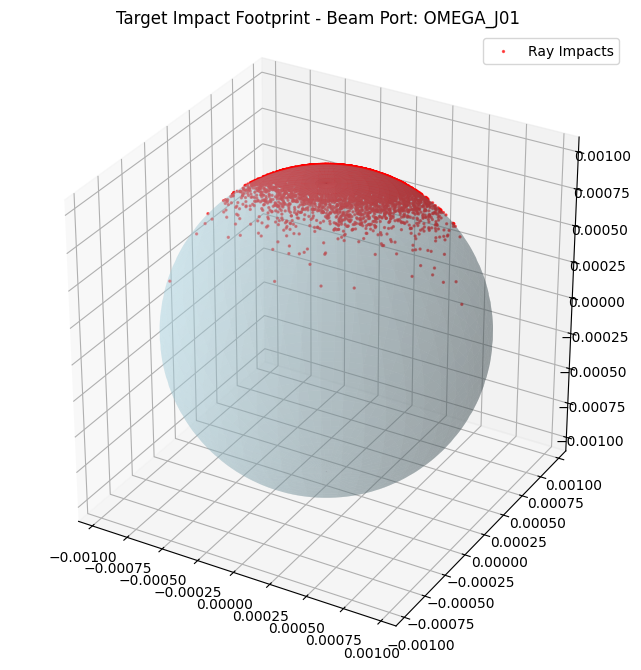

In [31]:
def plot_impact_footprint(impact_df, sphere_radius=TARGET_RADIUS):
    """
    Plots the 3D footprint of a single beam's rays on the target sphere.
    """
    # 1. Create 3D figure and axis
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 2. Draw the SOLID colored sphere (target)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    
    # Surface plot with transparency to see impacts on both sides
    ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                    color='lightblue', 
                    alpha=0.3,       # Transparency
                    linewidth=0, 
                    antialiased=True)

    # 3. Plot the impact points from the expanded DataFrame
    # Using the columns we just created: xsph_x, xsph_y, xsph_z
    xs = impact_df['xsph_x']
    ys = impact_df['xsph_y']
    zs = impact_df['xsph_z']
    
    # Scatter plot of the 10,000 rays (or as many as hit the target)
    ax.scatter(xs, ys, zs, color='red', s=2, alpha=0.6, label='Ray Impacts')

    # 4. Aesthetic configuration
    beam_id = impact_df['port'].iloc[0] if not impact_df.empty else "N/A"
    ax.set_title(f"Target Impact Footprint - Beam Port: {beam_id}")
    
    # Set axis limits to fit the sphere
    limit = sphere_radius * 1.1
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Set 1:1:1 aspect ratio so it looks like a sphere, not an egg
    ax.set_box_aspect([1, 1, 1])
    
    plt.legend()
    plt.show()

# --- Execution ---
# We use the expanded view we generated in the previous step
plot_impact_footprint(impact_1window_view, sphere_radius=TARGET_RADIUS)

## Simulation of hits from windows chosen by probability

### Simulation of impacts

In [32]:
def impact_simulated(
    num_beams_to_sample,
    num_samples_per_beam,
    target_radius,
    target_center
 ):
    # 1. USE THE EXPANDED DATAFRAME
    # Using df_beams_vista which already contains 't1_x', 'focus_x', etc.
    beam_df = df_omega.copy() 

    # 2. Probabilities based on energy
    ps = np.array(beam_df['energy'], dtype=float)
    ps /= np.sum(ps)

    # 3. Random beam selection (Monte Carlo)
    list_beams = np.arange(len(beam_df))
    selected_indices = np.random.choice(
        list_beams,
        size=num_beams_to_sample,
        p=ps
    )

    # 4. Impact simulation
    impact_list = []
    for i in selected_indices:
        # Extracting the row for the selected beam
        beam_row = beam_df.iloc[i]
        
        # Calling beam_hit (which in turn calls beam_sample)
        # IMPORTANT: center_target is the argument for the tracing function
        res = beam_hit(
            beam_row,
            num_samples_per_beam,
            radius=target_radius,
            center_target=target_center
        )
        
        if not res.empty:
            # Metadata should already come from beam_hit, but we ensure it here:
            res['port'] = beam_row['port']
            res['subwindow'] = beam_row['subwindow']
            impact_list.append(res)

    if not impact_list:
        print("Warning: No rays hit the target.")
        return pd.DataFrame()

    # 5. Concatenate all impact DataFrames
    impact_df = pd.concat(impact_list, ignore_index=True)

    return impact_df

### Simulation parameters

In [33]:
# Execution
total_impact = impact_simulated(
    num_beams_to_sample=100,
    num_samples_per_beam=1000, 
    target_radius=TARGET_RADIUS,
    target_center=np.array([0.0, 0.0, 0.0])
)

print(f"Simulación masiva completada.")
print(f"Total de impactos registrados: {len(total_impact)}")

Simulación masiva completada.
Total de impactos registrados: 99999


### Information of impacts in dataframe

In [34]:
def impact_df_vista(df_in):
    """
    Helper function to break down vectors in the impact DataFrame.
    """
    df = df_in.copy()
    
    # Function to efficiently expand vector columns
    def expand(df_target, col_name, names):
        if col_name in df_target.columns:
            temp = pd.DataFrame(df_target[col_name].tolist(), index=df_target.index)
            temp.columns = names
            return temp
        return pd.DataFrame()

    # Expand key vectors
    df_x = expand(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = expand(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = expand(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = expand(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expand spherical coordinates (sph: r, theta, phi)
    df_sph = expand(df, 'sph', ['r', 'theta', 'phi'])

    # Concatenate everything expanded with the original data
    return pd.concat([df.drop(columns=['x', 'u', 'xsph', 'n', 'sph'], errors='ignore'), 
                      df_x, df_u, df_xsph, df_n, df_sph], axis=1)

def preparar_dataframe_impactos(impact_df):
    # 1. Expand vectors and add spherical coordinates
    impact_df = impact_df_vista(impact_df)

    # 2. Ensure port and subwindow columns (avoid KeyErrors)
    if 'port' not in impact_df.columns: 
        impact_df['port'] = 'unknown'
    if 'subwindow' not in impact_df.columns:
        impact_df['subwindow'] = 'unknown'

    # 3. Select relevant columns according to the layout
    cols = [
        'port', 'subwindow', 'l', 'cs', 'theta', 'phi',
        'x_x', 'x_y', 'x_z',
        'u_x', 'u_y', 'u_z',
        'xsph_x', 'xsph_y', 'xsph_z',
        'n_x', 'n_y', 'n_z'
    ]
    available_cols = [c for c in cols if c in impact_df.columns]

    # 4. Round and return final DataFrame
    # Use copy() to avoid SettingWithCopyWarning
    formatted_df = impact_df[available_cols].copy()
    formatted_df = formatted_df.round(4)

    print(f"Valid impacts found: {len(formatted_df)}")
    return formatted_df

# --- Execution ---
df_impacts = preparar_dataframe_impactos(total_impact)
df_impacts

Valid impacts found: 99999


,port,subwindow,l,cs,theta,phi,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z
0,OMEGA_J32,0,1.6495,-0.9246,1.4702,1.3719,0.2968,-1.6235,0.0095,-0.1800,0.9836,-0.0057,-0.0002,-0.0010,0.0001,-0.1966,-0.9753,0.1004
1,OMEGA_J32,0,1.6493,-0.9629,1.6417,2.0548,0.3585,-1.6108,-0.0067,-0.2171,0.9761,0.0040,0.0005,-0.0009,-0.0001,0.4641,-0.8829,-0.0708
2,OMEGA_J32,0,1.6491,-0.9836,1.7474,1.6973,0.3260,-1.6175,-0.0166,-0.1976,0.9802,0.0100,0.0001,-0.0010,-0.0002,0.1242,-0.9766,-0.1757
3,OMEGA_J32,0,1.6493,-0.9509,1.8272,1.9891,0.3521,-1.6121,-0.0240,-0.2132,0.9769,0.0144,0.0004,-0.0009,-0.0003,0.3930,-0.8839,-0.2536
4,OMEGA_J32,0,1.6491,-0.9900,1.4230,1.7468,0.3304,-1.6166,0.0139,-0.2003,0.9797,-0.0083,0.0002,-0.0010,0.0001,0.1732,-0.9738,0.1473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,OMEGA_J46,0,1.6490,-0.9998,2.0086,2.7814,1.4096,-0.5380,-0.6678,-0.8543,0.3261,0.4047,0.0008,-0.0003,-0.0004,0.8475,-0.3192,-0.4240
99995,OMEGA_J46,0,1.6490,-0.9954,1.9625,2.8842,1.4144,-0.5302,-0.6640,-0.8572,0.3214,0.4024,0.0009,-0.0002,-0.0004,0.8938,-0.2352,-0.3818
99996,OMEGA_J46,0,1.6491,-0.9892,2.1122,2.8807,1.4088,-0.5291,-0.6769,-0.8538,0.3207,0.4101,0.0008,-0.0002,-0.0005,0.8280,-0.2211,-0.5153
99997,OMEGA_J46,0,1.6495,-0.9307,2.1739,2.3750,1.3918,-0.5643,-0.6843,-0.8434,0.3418,0.4145,0.0006,-0.0006,-0.0006,0.5932,-0.5713,-0.5672


### Pyvista (3D representation)

## Histogram of impacts in a 1m radius sphere

### Divides the sphere in sectors

In [35]:
class SphereSectors():
    def __init__(self, num_theta, num_phi):
      # Create the theta-phi grid edges
      self.theta_edges = np.linspace(0, np.pi, num_theta + 1)  # includes poles
      self.phi_edges = np.linspace(0, 2 * np.pi, num_phi + 1)  # includes closure

      # Coordinates of the spherical sector centers
      self.theta = 0.5 * (self.theta_edges[:-1] + self.theta_edges[1:])
      self.phi = 0.5 * (self.phi_edges[:-1] + self.phi_edges[1:])

      self.mtheta, self.mphi = np.meshgrid(self.theta, self.phi, indexing='ij')       

      return

sectors = SphereSectors( num_theta = 50, num_phi = 50)

### Representation of the mesh

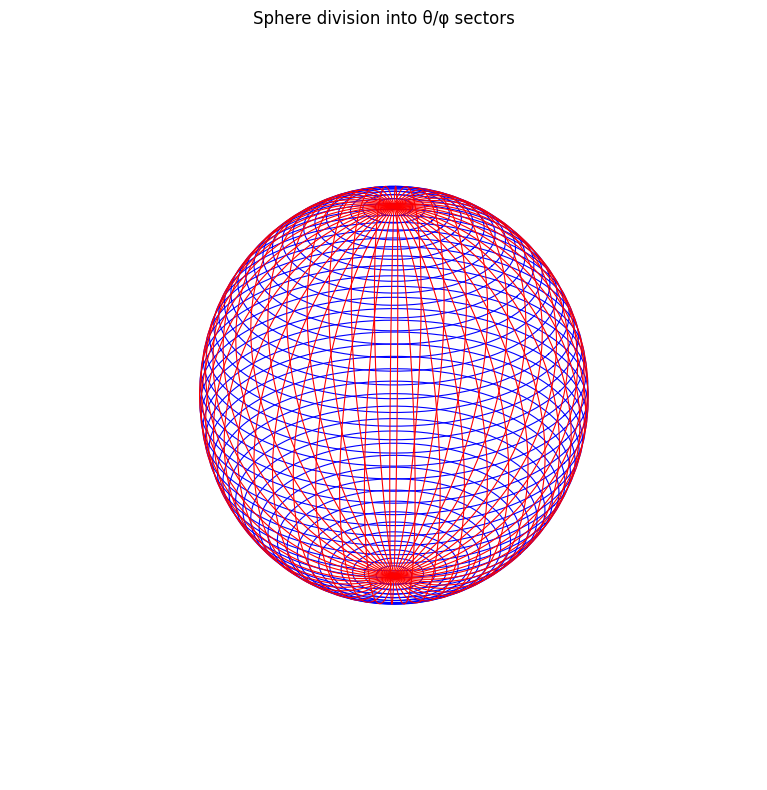

In [36]:
# Parameters
radius = TARGET_RADIUS

# Create 3D figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw horizontal lines (theta)
phi = np.linspace(0, 2 * np.pi, 200)
for theta in sectors.theta:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='blue', linewidth=0.8)

# Draw vertical lines (phi)
theta = np.linspace(0, np.pi, 200)
for phi in sectors.phi:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='red', linewidth=0.8)

# Aesthetics
ax.set_box_aspect([1, 1, 1])
ax.set_title("Sphere division into θ/φ sectors")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Function to calculate the area of sectors of the mesh

In [37]:
def spherical_sector_area( theta1, theta2, phi1, phi2, radius=1., ):
    """
    Calculates the surface area of a spherical sector (a cell on the grid)
    defined by theta and phi boundaries.
    """
    # Calculate the area of the spherical zone (ring) between theta1 and theta2
    area_anillo = 2 * np.pi * radius**2 * np.abs(np.cos(theta1) - np.cos(theta2))
    
    # Calculate the longitudinal span
    delta_phi = np.abs(phi2 - phi1)
    
    # The sector area is the fraction of the ring corresponding to delta_phi
    area_sector = (delta_phi / (2 * np.pi)) * area_anillo
    return area_sector

# Calculate the area for all grid cells using broadcasting
sectors.area = spherical_sector_area( 
    sectors.theta_edges[:-1][:,None], 
    sectors.theta_edges[1:][:,None], 
    sectors.phi_edges[:-1][None,:], 
    sectors.phi_edges[1:][None,:], 
    radius=1. 
)

# Verification: the sum of all sector areas must equal the total sphere area (4*pi*r^2)
assert np.isclose( np.sum( sectors.area ), 4.*np.pi, atol=1e-4 ), "The calculated total area does not match the sphere's surface area."

### Plots the centers of each sector in the sphere mesh

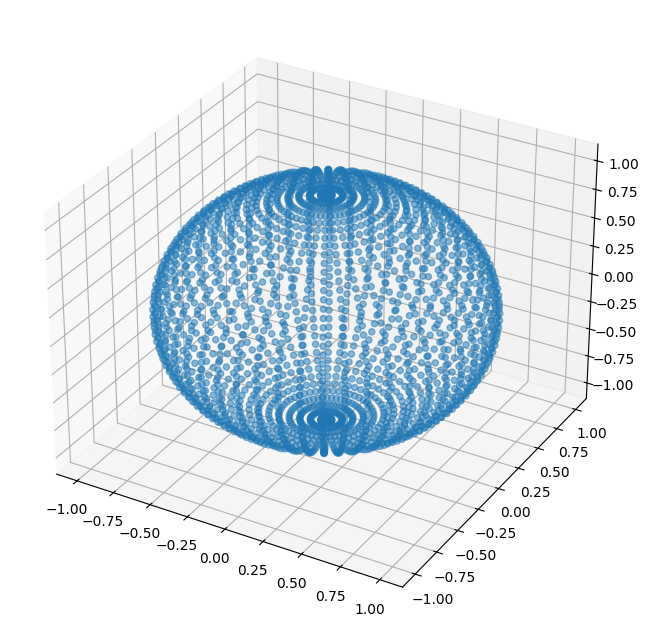

In [38]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = test.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)
ax.scatter( xs, ys, zs, alpha=0.5)

### Creates energy histogram in sphere

In [39]:
def hist(hits, sectors):
    # 2D Histogram with weights
    hs_raw, _, _ = np.histogram2d(
        hits['theta'],
        hits['phi'],
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=np.abs(hits['cs'])
    )

    # Density per unit area
    hs = hs_raw / sectors.area

    # Conservation validation
    assert np.isclose(
        np.sum(hs * sectors.area),
        np.sum(np.abs(hits['cs'])),
        atol=1e-4
    ), "The weighted sum does not match the original sum of |cs|."

    # Normalization for visualization
    hs_norm = (hs - np.min(hs)) / (np.max(hs) - np.min(hs))

    # Final DataFrame
    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist

In [40]:
hits = df_impacts[df_impacts['cs'] < 0]

In [41]:
# On force les valeurs à rester dans les limites de la sphère
hits['theta'] = np.clip(hits['theta'], 0, np.pi)
hits['phi'] = np.clip(hits['phi'], 0, 2*np.pi)

# Maintenant tu peux lancer le calcul sans erreur
df_hist = hist(hits, sectors)

df_hist = hist(hits, sectors)

hs = df_hist['hs_density'].values

### Histogram graphic

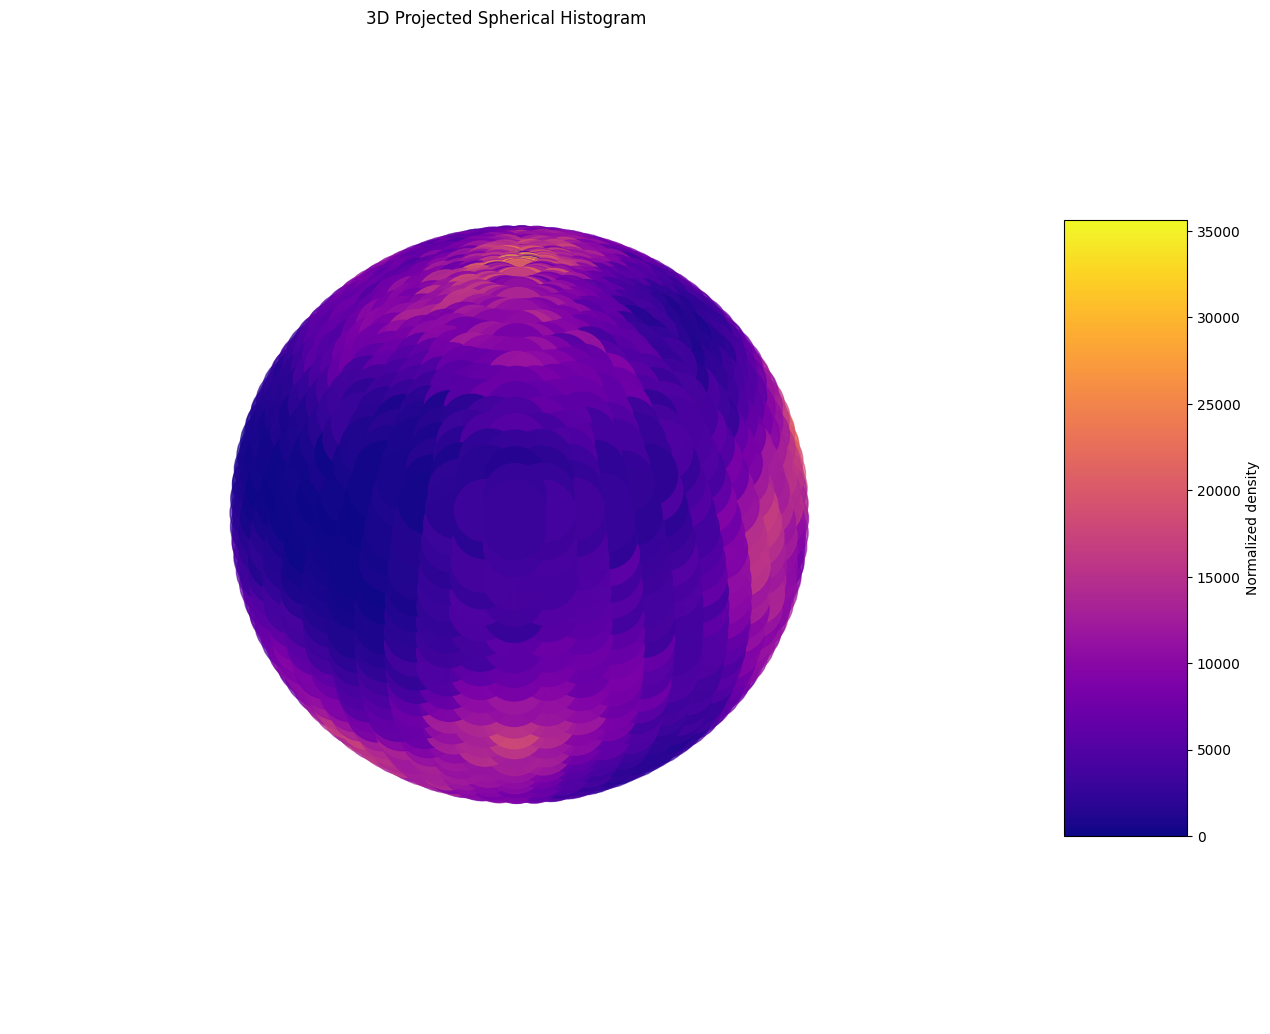

In [43]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Convert sector centers to Cartesian coordinates
xs, ys, zs = test.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Flatten for scatter plot
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs should be the normalized histogram or density

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=2000)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Normalized density")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Projected Spherical Histogram")
ax.set_axis_off()

plt.show()

### Pyvista histogram graphic

### Analyse with spherical harmonics

In [ ]:

from scipy.special import sph_harm

In [ ]:
def compute_omega_coeffs(df_hist, n_theta, n_phi, Lmax=8):
    # 1. Reshape the DataFrame into a 2D grid
    hist_2d = df_hist['hs_density'].values.reshape((n_theta, n_phi))
    
    # 2. Prepare the angular coordinates
    theta_edges = np.linspace(0, np.pi, n_theta + 1)
    phi_edges = np.linspace(0, 2 * np.pi, n_phi + 1)
    theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
    phi_centers   = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    
    # 3. Coordinate grid
    mt, mp = np.meshgrid(theta_centers, phi_centers, indexing='ij')

    # 4. Calculate the area of each bin (S)
    dphi = phi_edges[1:] - phi_edges[:-1]
    dtheta_cos = np.cos(theta_edges[:-1]) - np.cos(theta_edges[1:])
    S = np.outer(dtheta_cos, dphi)

    # 5. Compute the spherical harmonic coefficients
    total_energy = np.sum(hist_2d * S)
    coeffs = {}
    for l in range(Lmax + 1):
        for m in range(-l, l + 1):
            Ylm = sph_harm(m, l, mp, mt)
            alm = np.sum(hist_2d * np.conjugate(Ylm) * S)
            coeffs[(l, m)] = alm / total_energy
    return coeffs

def display_results(coeffs):
    # Table header with the requested columns
    print("\n" + "="*95)
    print(f"{'l':>3} {'m':>4} {'Re(a_lm)':>15} {'Im(a_lm)':>15} {'|a_lm|':>15} {'|a_lm|/|a_00|':>15}")
    print("-" * 95)
    
    # Normalization reference (monopole mode l=0, m=0)
    a_00 = coeffs[(0,0)]
    norm = abs(a_00)

    for (l, m), val in sorted(coeffs.items()):
        # Extract the different components
        re_part = val.real
        im_part = val.imag
        magnitude = abs(val)
        
        # Calculate the ratio relative to the average illumination
        if norm == 0:
            ratio = float('nan')
        else:
            ratio = magnitude / norm

        # Display: always show l=0 as a reference, 
        # then other modes if they exceed the 0.01% defect threshold.
        if l == 0:
            print(f"{l:3d} {m:4d} {re_part:15.6e} {im_part:15.6e} {magnitude:15.6e} {ratio:15.6f}")
            print("-" * 95) # Separator line after the fundamental mode
        elif ratio > 0.0001: 
            print(f"{l:3d} {m:4d} {re_part:15.6e} {im_part:15.6e} {magnitude:15.6e} {ratio:15.6f}")
            
    print("="*95 + "\n")

In [ ]:
# dimensions  (50x50)
results = compute_omega_coeffs(df_hist, 50, 50, Lmax=8)
display_results(results)


  l    m        Re(a_lm)        Im(a_lm)          |a_lm|   |a_lm|/|a_00|
-----------------------------------------------------------------------------------------------
  0    0    2.820948e-01    0.000000e+00    2.820948e-01        1.000000
-----------------------------------------------------------------------------------------------
  1   -1    5.666072e-03   -4.119519e-02    4.158302e-02        0.147408
  1    0   -5.167236e-03    0.000000e+00    5.167236e-03        0.018317
  1    1   -5.666072e-03   -4.119519e-02    4.158302e-02        0.147408
  2   -2    1.342636e-02   -6.702671e-03    1.500643e-02        0.053196
  2   -1   -4.183249e-02   -1.360761e-02    4.399005e-02        0.155941
  2    0    8.222253e-02    0.000000e+00    8.222253e-02        0.291471
  2    1    4.183249e-02   -1.360761e-02    4.399005e-02        0.155941
  2    2    1.342636e-02    6.702671e-03    1.500643e-02        0.053196
  3   -3   -1.256461e-03   -2.273687e-03    2.597758e-03        0.009209
  3 

C:\Users\clara\AppData\Local\Temp\ipykernel_4940\1955605505.py:24: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylm = sph_harm(m, l, mp, mt)
